In [1]:
from google.colab import files
uploaded = files.upload()

Saving players_data-2025_2026.csv to players_data-2025_2026.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('players_data-2025_2026.csv')
df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
0,1,Brenden Aaronson,us USA,"FW,MF",Leeds United,eng Premier League,25.0,2000.0,20,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Zach Abbott,eng ENG,DF,Nott'ham Forest,eng Premier League,19.0,2006.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Jones El-Abdellaoui,ma MAR,"FW,MF",Celta Vigo,es La Liga,20.0,2006.0,10,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Himad Abdelli,dz ALG,MF,Angers,fr Ligue 1,26.0,1999.0,13,11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Ali Abdi,tn TUN,"DF,MF",Nice,fr Ligue 1,32.0,1993.0,9,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Data Frame Check

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2433 entries, 0 to 2432
Columns: 267 entries, Rk to AvgDist
dtypes: float64(101), int64(121), object(45)
memory usage: 5.0+ MB


In [4]:
# All Data Frame Column Check

df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts',
       ...
       'Att (GK)', 'Thr', 'Launch%', 'AvgLen', 'Opp', 'Stp', 'Stp%', '#OPA',
       '#OPA/90', 'AvgDist'],
      dtype='object', length=267)

In [5]:
# Goalkeeper Filter

df_gk = df[df['Pos'] == 'GK'].copy()
df_gk.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Att (GK),Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist
32,33,Julen Agirrezabala,es ESP,GK,Valencia,es La Liga,25.0,2000.0,18,18,...,468.0,73.0,32.1,32.2,217.0,23.0,10.6,40.0,2.22,17.2
67,68,Alisson,br BRA,GK,Liverpool,eng Premier League,33.0,1992.0,16,16,...,532.0,71.0,23.1,29.1,196.0,12.0,6.1,16.0,1.00,13.3
114,115,Alphonse Areola,fr FRA,GK,West Ham,eng Premier League,32.0,1993.0,17,17,...,383.0,82.0,52.5,40.1,300.0,14.0,4.7,2.0,0.12,6.7
117,118,Paul Argney,fr FRA,GK,Le Havre,fr Ligue 1,19.0,2006.0,1,1,...,28.0,3.0,25.0,27.3,18.0,1.0,5.6,0.0,0.00,5.0
139,140,Noah Atubolu,de GER,GK,Freiburg,de Bundesliga,23.0,2002.0,16,16,...,610.0,64.0,39.7,35.4,184.0,10.0,5.4,30.0,1.88,17.1


In [6]:
# Goalkeeper Data Frame Column Check

df_gk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 150 entries, 32 to 2422
Columns: 267 entries, Rk to AvgDist
dtypes: float64(101), int64(121), object(45)
memory usage: 314.1+ KB


In [7]:
# Goalkeeper Match Played Data Check

df_gk['MP'].describe()

,MP
count,150.000000
mean,11.933333
std,6.663198
min,1.000000
25%,5.000000
50%,15.000000
75%,17.000000
max,21.000000


In [8]:
# Goalkeeper Minutes Played Data Check

df_gk['Min'].describe()

,Min
count,150.000000
mean,1064.293333
std,602.147862
min,76.000000
25%,450.000000
50%,1320.000000
75%,1530.000000
max,1890.000000


In [9]:
# Goalkeeper Baseline Filter

baseline_min = df_gk['Min'].median()

df_gk_filtered = df_gk[df_gk['Min'] >= baseline_min].copy()

print("Sebelum filter:", df_gk.shape[0])
print("Sesudah filter:", df_gk_filtered.shape[0])

Sebelum filter: 150
Sesudah filter: 75


In [10]:
# Goalkeeper Minutes Played After Filter

df_gk_filtered['Min'].describe()

,Min
count,75.000000
mean,1583.720000
std,180.739514
min,1336.000000
25%,1440.000000
50%,1530.000000
75%,1710.000000
max,1890.000000


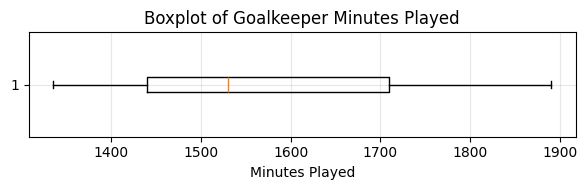

In [11]:
# Visualization Goalkeeper Minutes Played Filter

minutes = df_gk_filtered['Min']

plt.figure(figsize=(6, 2))
plt.boxplot(minutes, vert=False)

plt.title('Boxplot of Goalkeeper Minutes Played')
plt.xlabel('Minutes Played')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Goalkeeper Filter Validation

df_gk_filtered['Min_per_MP'] = (
    df_gk_filtered['Min'] / df_gk_filtered['MP']
)

df_gk_filtered = df_gk_filtered[
    df_gk_filtered['Min_per_MP'] >= 85
]

df_gk_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 32 to 2323
Columns: 268 entries, Rk to Min_per_MP
dtypes: float64(102), int64(121), object(45)
memory usage: 157.6+ KB


In [13]:
# Goalkeeper Filter List Check

df_gk_filtered.sort_values('Min').head(5)[
    ['Player', 'Squad', 'Min', 'MP']
]

,Player,Squad,Min,MP
1826,Nick Pope,Newcastle Utd,1336,15
206,Oliver Baumann,Hoffenheim,1350,15
446,Lucas Chevalier,Paris S-G,1350,15
141,Emil Audero,Cremonese,1350,15
923,Péter Gulácsi,RB Leipzig,1350,15


In [14]:
# Goalkeeper Filter Cleaning

df_gk_filtered.reset_index(drop=True, inplace=True)

df_gk_filtered.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Thr,Launch%,AvgLen,Opp,Stp,Stp%,#OPA,#OPA/90,AvgDist,Min_per_MP
0,33,Julen Agirrezabala,es ESP,GK,Valencia,es La Liga,25.0,2000.0,18,18,...,73.0,32.1,32.2,217.0,23.0,10.6,40.0,2.22,17.2,90.0
1,68,Alisson,br BRA,GK,Liverpool,eng Premier League,33.0,1992.0,16,16,...,71.0,23.1,29.1,196.0,12.0,6.1,16.0,1.00,13.3,90.0
2,115,Alphonse Areola,fr FRA,GK,West Ham,eng Premier League,32.0,1993.0,17,17,...,82.0,52.5,40.1,300.0,14.0,4.7,2.0,0.12,6.7,90.0
3,140,Noah Atubolu,de GER,GK,Freiburg,de Bundesliga,23.0,2002.0,16,16,...,64.0,39.7,35.4,184.0,10.0,5.4,30.0,1.88,17.1,90.0
4,142,Emil Audero,id IDN,GK,Cremonese,it Serie A,28.0,1997.0,15,15,...,84.0,40.2,35.6,251.0,24.0,9.6,10.0,0.67,11.0,90.0


In [15]:
# Goalkeeper Data Clean Check

df_gk_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Columns: 268 entries, Rk to Min_per_MP
dtypes: float64(102), int64(121), object(45)
memory usage: 157.2+ KB


In [16]:
# Goalkeeper League Origin Check

df_gk_filtered['Comp'].value_counts()

,count
Comp,
eng Premier League,19
it Serie A,16
es La Liga,15
de Bundesliga,14
fr Ligue 1,11


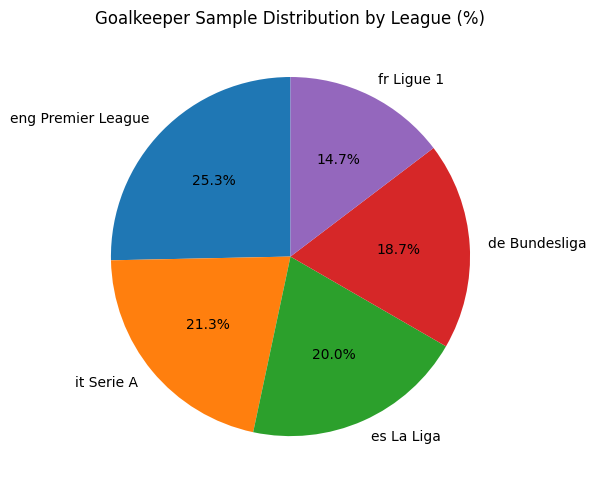

In [17]:
# Visualization Sample Distribution

league_counts = df_gk_filtered['Comp'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    league_counts,
    labels=league_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Goalkeeper Sample Distribution by League (%)')
plt.tight_layout()
plt.show()

In [18]:
# Goalkeeper Feature/Metric Check

cols = ['GA', 'Saves', 'CS', 'PKsv', 'PrgP', 'Save%', 'Cmp%']
df_gk_filtered[cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GA      75 non-null     float64
 1   Saves   75 non-null     float64
 2   CS      75 non-null     float64
 3   PKsv    75 non-null     float64
 4   PrgP    75 non-null     int64  
 5   Save%   75 non-null     float64
 6   Cmp%    75 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 4.2 KB


In [19]:
# Defining Goalkeeper Feature/Metric Normalization

per90_metrics = ['GA', 'Saves', 'CS', 'PKsv', 'PrgP']

for col in per90_metrics:
    df_gk_filtered[f'{col}_per90'] = (
        df_gk_filtered[col] / df_gk_filtered['Min'] * 90
    )

df_gk_filtered[[f'{c}_per90' for c in per90_metrics]].describe()

,GA_per90,Saves_per90,CS_per90,PKsv_per90,PrgP_per90
count,75.000000,75.000000,75.000000,75.000000,75.000000
mean,1.324387,2.857212,0.280796,0.033317,0.043267
std,0.377750,0.628539,0.124833,0.043885,0.070317
min,0.600000,1.523810,0.000000,0.000000,0.000000
25%,1.059649,2.466667,0.187500,0.000000,0.000000
50%,1.315789,2.800000,0.263158,0.000000,0.000000
75%,1.562500,3.295139,0.375000,0.062500,0.064583
max,2.250000,4.789474,0.500000,0.142857,0.250000


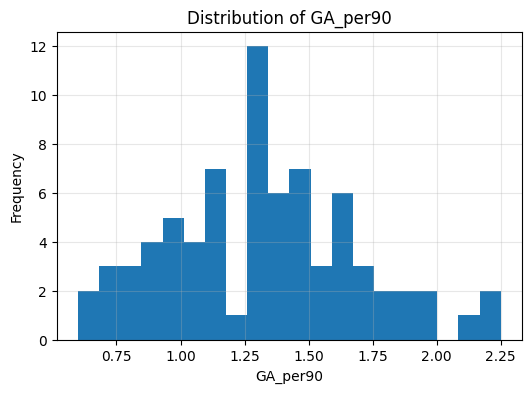

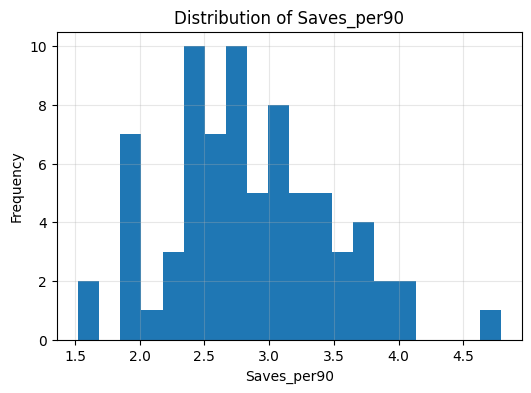

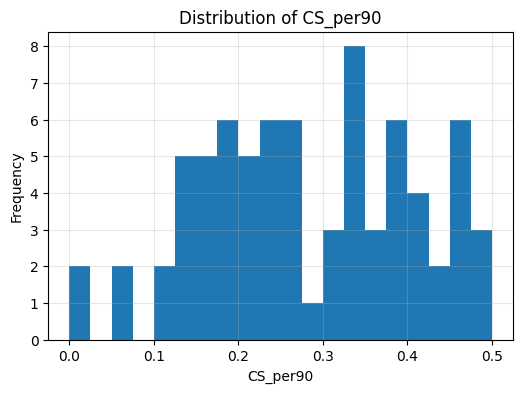

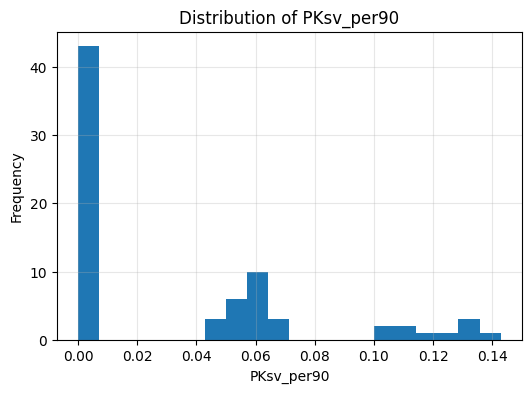

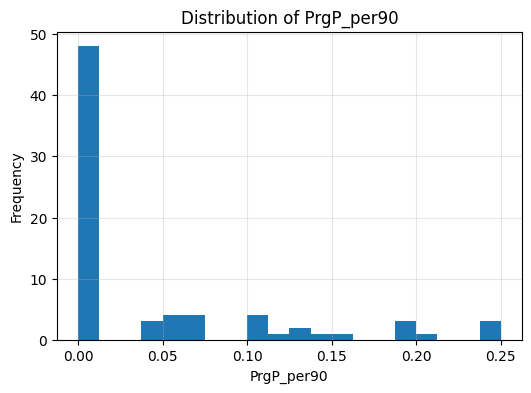

In [20]:
# Visualization Goalkeeper Feature/Metric Normalization

per90_cols = [f'{c}_per90' for c in per90_metrics]

for col in per90_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df_gk_filtered[col], bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.show()

In [21]:
# Goalkeeper Feature/Metric Scale Normalization

metrics_for_scaling = [
    'GA_per90', 'Saves_per90', 'CS_per90',
    'Save%',
    'PKsv_per90', 'PrgP_per90',
    'Cmp%'
]

for col in metrics_for_scaling:
    df_gk_filtered[f'{col}_z'] = (
        df_gk_filtered[col] - df_gk_filtered[col].mean()
    ) / df_gk_filtered[col].std()

df_gk_filtered[
    [col for col in df_gk_filtered.columns if col.endswith('_z')]
].describe().round(3)

,GA_per90_z,Saves_per90_z,CS_per90_z,Save%_z,PKsv_per90_z,PrgP_per90_z,Cmp%_z
count,75.000,75.000,75.000,75.000,75.000,75.000,75.000
mean,-0.000,-0.000,0.000,-0.000,0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.918,-2.121,-2.249,-2.212,-0.759,-0.615,-2.872
25%,-0.701,-0.621,-0.747,-0.524,-0.759,-0.615,-0.425
50%,-0.023,-0.091,-0.141,-0.037,-0.759,-0.615,0.079
75%,0.630,0.697,0.755,0.520,0.665,0.303,0.728
max,2.450,3.074,1.756,2.104,2.496,2.940,1.932


In [22]:
# Z-Score Definition

z_metrics = [
    'GA_per90_z',
    'Saves_per90_z',
    'CS_per90_z',
    'Save%_z',
    'PKsv_per90_z',
    'PrgP_per90_z',
    'Cmp%_z'
]

df_gk_filtered[z_metrics].head()

,GA_per90_z,Saves_per90_z,CS_per90_z,Save%_z,PKsv_per90_z,PrgP_per90_z,Cmp%_z
0,0.906101,-0.037991,-0.469217,-0.784986,0.506747,0.174759,0.234757
1,-0.527827,-1.363818,0.754641,-0.906806,-0.759183,2.940000,1.055740
2,1.477076,1.350228,-2.249374,0.015547,-0.759183,-0.615310,-1.895363
3,0.961252,-0.866633,-0.246697,-2.212022,0.664989,2.051173,-0.175735
4,-0.682250,2.030299,0.420862,1.895058,-0.759183,-0.615310,-0.863586


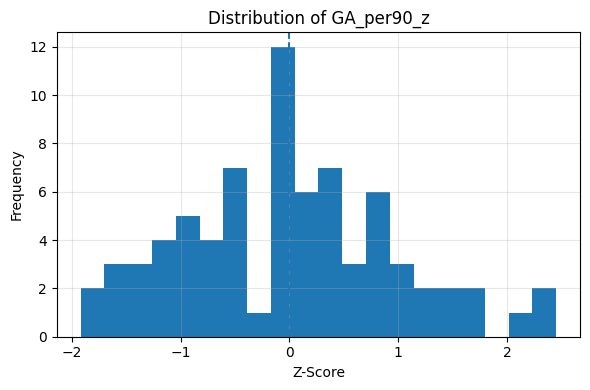

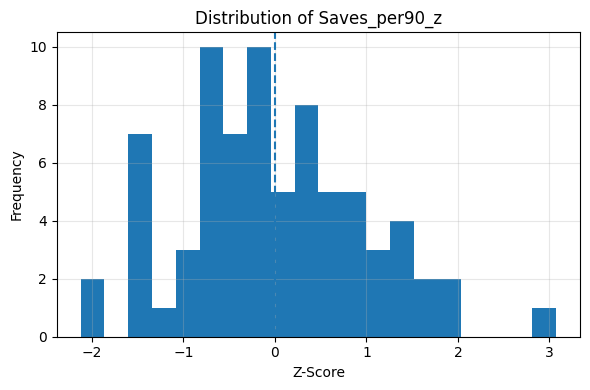

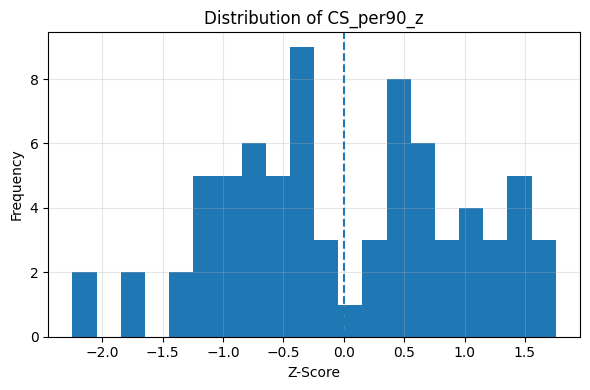

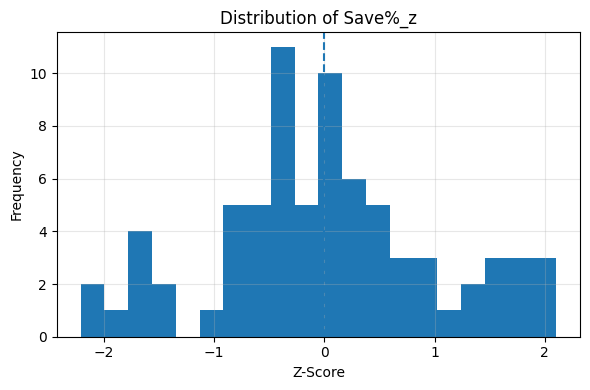

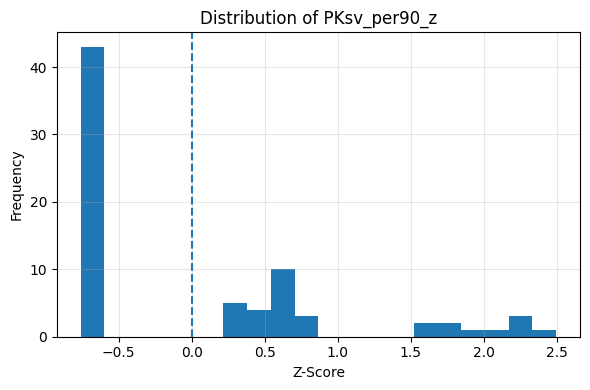

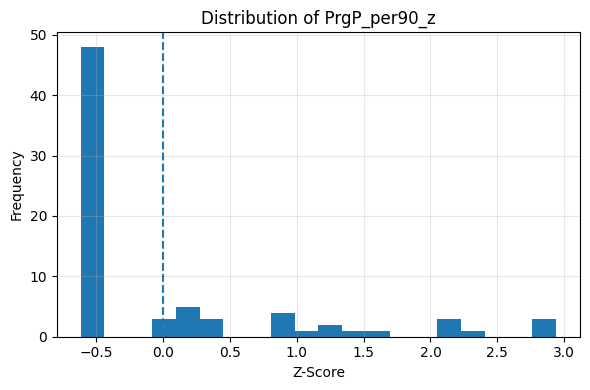

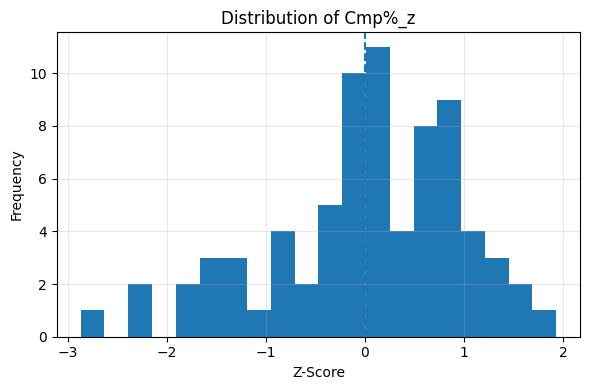

In [23]:
# Visualization Goalkeeper Feature/Metric Scale Normalization

z_cols = [col for col in df_gk_filtered.columns if col.endswith('_z')]

for col in z_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df_gk_filtered[col], bins=20)
    plt.axvline(0, linestyle='--')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Z-Score')
    plt.ylabel('Frequency')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

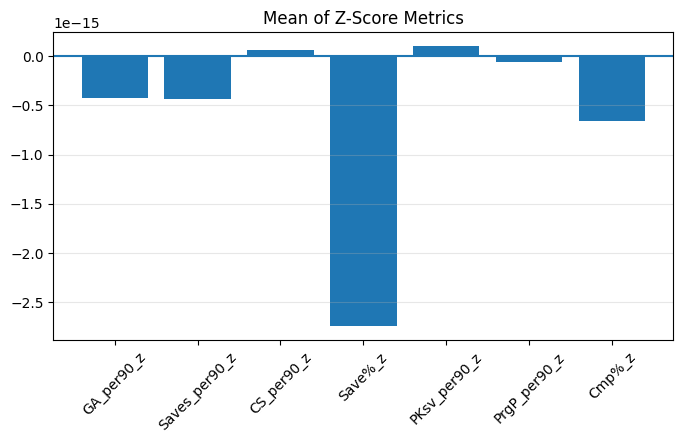

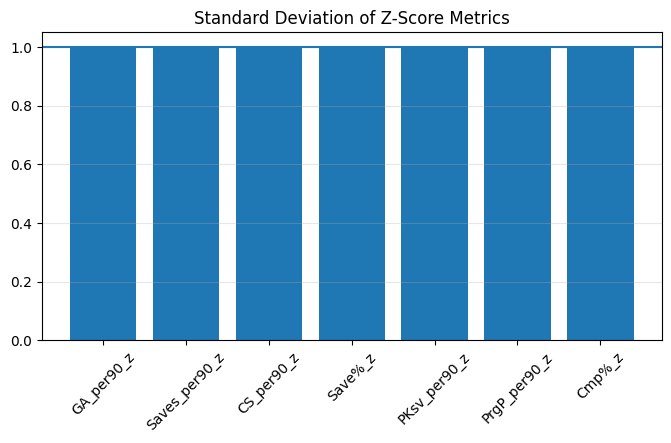

In [24]:
# Visualization Goalkeeper Feature/Metric Scale Normalization

means = df_gk_filtered[z_cols].mean()
stds = df_gk_filtered[z_cols].std()

plt.figure(figsize=(8,4))
plt.bar(means.index, means.values)
plt.axhline(0)
plt.title('Mean of Z-Score Metrics')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(8,4))
plt.bar(stds.index, stds.values)
plt.axhline(1)
plt.title('Standard Deviation of Z-Score Metrics')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

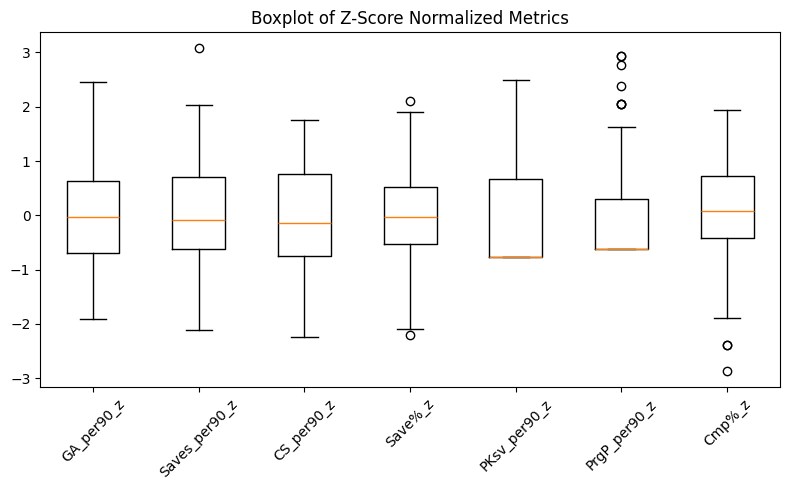

In [25]:
# Visualization Goalkeeper Feature/Metric Scale Normalization

plt.figure(figsize=(8,5))
plt.boxplot(df_gk_filtered[z_cols])
plt.xticks(range(1, len(z_cols)+1), z_cols, rotation=45)
plt.title('Boxplot of Z-Score Normalized Metrics')
plt.tight_layout()
plt.show()

In [26]:
# Reverse Negative Feature/Metric

df_gk_filtered['GA_per90_z'] *= -1

In [27]:
# Feature/Metric Grouping

group_map = {
    'Save%_z': 'shot',
    'Saves_per90_z': 'shot',
    'PKsv_per90_z': 'shot',

    'GA_per90_z': 'outcome',
    'CS_per90_z': 'outcome',

    'PrgP_per90_z': 'dist',
    'Cmp%_z': 'dist'
}

In [28]:
# Feature/Metric Grouping Distribution

group_target = {
    'shot': 0.70,
    'outcome': 0.20,
    'dist': 0.10
}

In [29]:
# PCA

from sklearn.decomposition import PCA

X = df_gk_filtered[z_metrics]
pca = PCA()
pca.fit(X)

weights = abs(pca.components_[0])
weights = weights / weights.sum()

pd.Series(weights, index=z_metrics)

,0
GA_per90_z,0.259521
Saves_per90_z,0.107717
CS_per90_z,0.253406
Save%_z,0.180443
PKsv_per90_z,0.010548
PrgP_per90_z,0.041944
Cmp%_z,0.146421


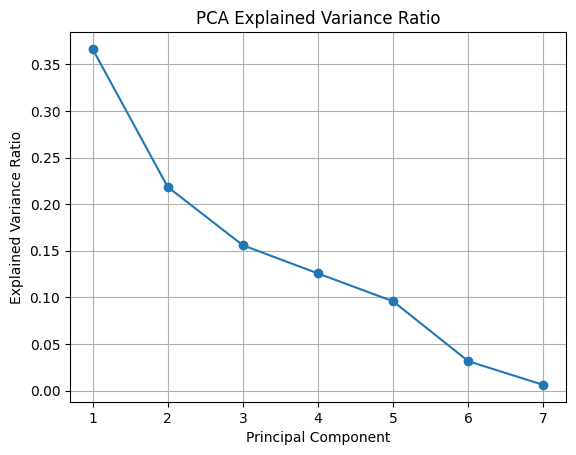

In [30]:
# Visualization PCA

explained_var = pca.explained_variance_ratio_

plt.figure()
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o')
plt.title('PCA Explained Variance Ratio')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

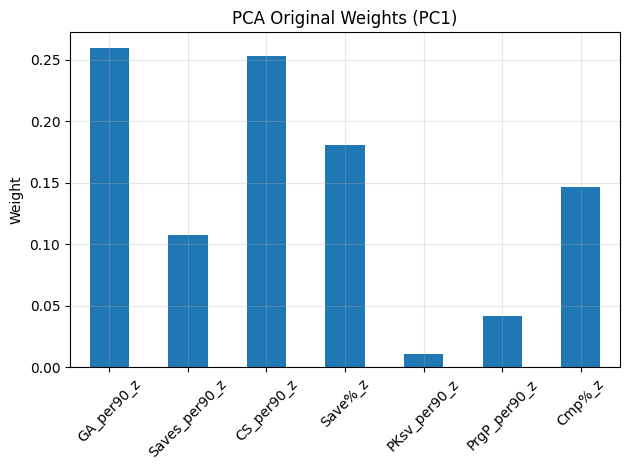

GA_per90_z       0.259521
Saves_per90_z    0.107717
CS_per90_z       0.253406
Save%_z          0.180443
PKsv_per90_z     0.010548
PrgP_per90_z     0.041944
Cmp%_z           0.146421
dtype: float64


In [31]:
# Visualization PCA

weights_original = abs(pca.components_[0])
weights_original = weights_original / weights_original.sum()

weights_original_series = pd.Series(weights_original, index=z_metrics)

plt.figure()
weights_original_series.plot(kind='bar')

plt.title('PCA Original Weights (PC1)')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(weights_original_series)

In [32]:
# Goalkeeper Performance Index

weights_pca = pd.Series({
    'GA_per90_z': 0.259521,
    'Saves_per90_z': 0.107717,
    'CS_per90_z': 0.253406,
    'Save%_z': 0.180443,
    'PKsv_per90_z': 0.010548,
    'PrgP_per90_z': 0.041944,
    'Cmp%_z': 0.146421
})

df_gk_filtered['GK_Index'] = (
    df_gk_filtered[weights_pca.index] * weights_pca
).sum(axis=1)

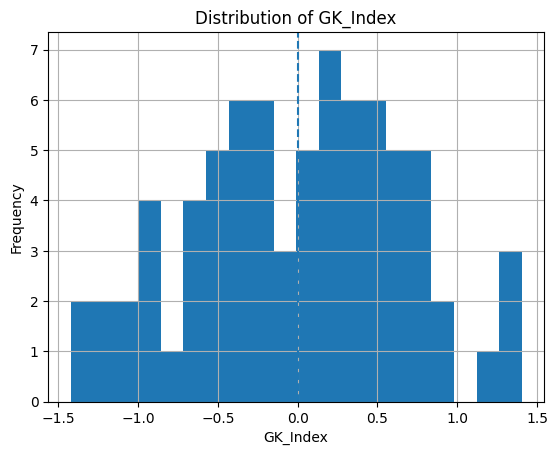

In [33]:
# Visualization Goalkeeper Performance Index

plt.figure()
plt.hist(df_gk_filtered['GK_Index'], bins=20)
plt.axvline(df_gk_filtered['GK_Index'].mean(), linestyle='--')
plt.title('Distribution of GK_Index')
plt.xlabel('GK_Index')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [34]:
# PCA Re-Scaling

weights_adjusted = weights_pca.copy()

for group in group_target:
    cols = [m for m, g in group_map.items() if g == group]
    current_sum = weights_pca[cols].sum()
    weights_adjusted[cols] = (
        weights_pca[cols] / current_sum * group_target[group]
    )

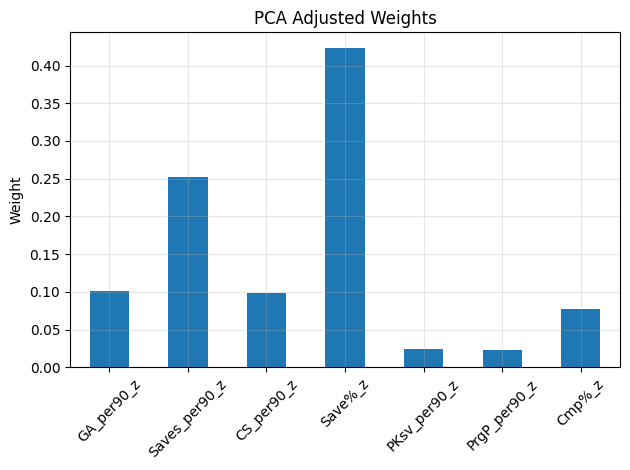

GA_per90_z       0.101192
Saves_per90_z    0.252427
CS_per90_z       0.098808
Save%_z          0.422855
PKsv_per90_z     0.024718
PrgP_per90_z     0.022267
Cmp%_z           0.077733
dtype: float64


In [35]:
# Visualization PCA After Re-Scaling

plt.figure()
weights_adjusted.plot(kind='bar')

plt.title('PCA Adjusted Weights')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(weights_adjusted)

<Figure size 640x480 with 0 Axes>

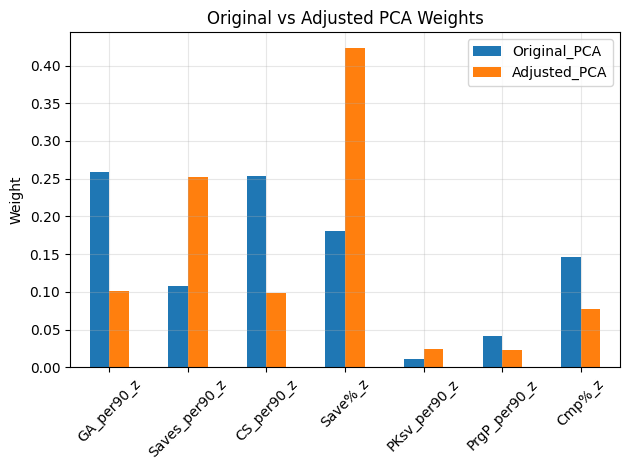

               Original_PCA  Adjusted_PCA
GA_per90_z         0.259521      0.101192
Saves_per90_z      0.107717      0.252427
CS_per90_z         0.253406      0.098808
Save%_z            0.180443      0.422855
PKsv_per90_z       0.010548      0.024718
PrgP_per90_z       0.041944      0.022267
Cmp%_z             0.146421      0.077733


In [36]:
# Visualization PCA Comparison

comparison_df = pd.DataFrame({
    'Original_PCA': weights_original_series,
    'Adjusted_PCA': weights_adjusted
})

plt.figure()
comparison_df.plot(kind='bar')

plt.title('Original vs Adjusted PCA Weights')
plt.ylabel('Weight')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(comparison_df)

In [37]:
# Goalkeeper Index Final

df_gk_filtered['GK_Index_adj'] = (
    df_gk_filtered[weights_adjusted.index] * weights_adjusted
).sum(axis=1)

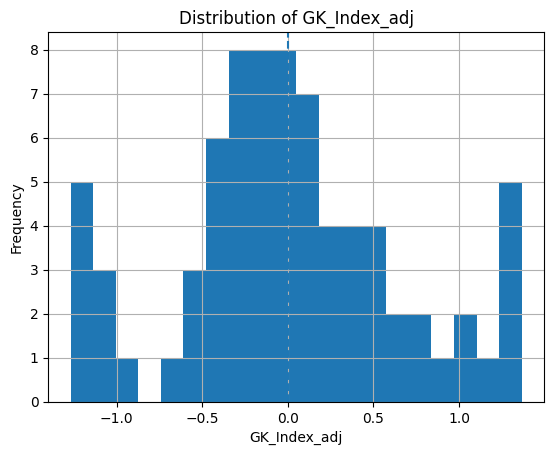

In [38]:
# Visualization Goalkeeper Index Final

plt.figure()
plt.hist(df_gk_filtered['GK_Index_adj'], bins=20)
plt.axvline(df_gk_filtered['GK_Index_adj'].mean(), linestyle='--')
plt.title('Distribution of GK_Index_adj')
plt.xlabel('GK_Index_adj')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

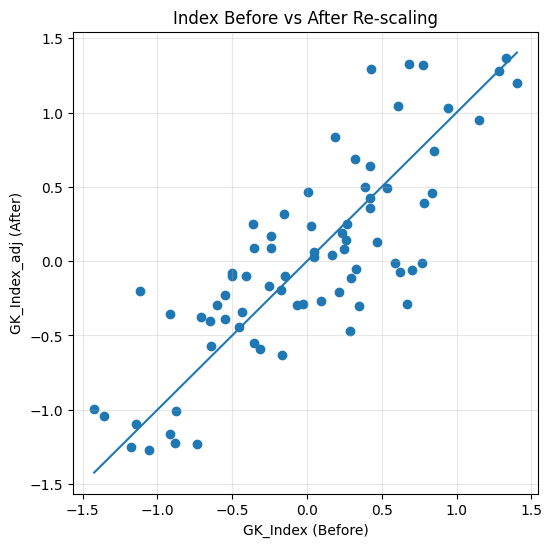

Correlation: 0.8154749650533161


In [39]:
# Visualization Comparison Index Before-After

x = df_gk_filtered['GK_Index']
y = df_gk_filtered['GK_Index_adj']

plt.figure(figsize=(6,6))
plt.scatter(x, y)

# garis diagonal
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("GK_Index (Before)")
plt.ylabel("GK_Index_adj (After)")
plt.title("Index Before vs After Re-scaling")

plt.grid(alpha=0.3)
plt.show()

# tampilkan korelasi
print("Correlation:", df_gk_filtered[['GK_Index','GK_Index_adj']].corr().iloc[0,1])

In [40]:
# Goalkeeper Index Adj Validation 1

df_gk_filtered[['GK_Index_adj', 'CS_per90']].corr()

,GK_Index_adj,CS_per90
GK_Index_adj,1.000000,0.474973
CS_per90,0.474973,1.000000


In [41]:
# New Goalkeeper Index Validation 2

df_gk_filtered[['GK_Index_adj', 'Saves_per90']].corr()

,GK_Index_adj,Saves_per90
GK_Index_adj,1.000000,0.465197
Saves_per90,0.465197,1.000000


In [42]:
# Goalkeeper Ranking

df_ranked = (
    df_gk_filtered
    .sort_values('GK_Index_adj', ascending=False)
    .reset_index(drop=True)
)

df_ranked[['Player', 'Squad', 'Comp', 'GK_Index_adj']].head(75)

,Player,Squad,Comp,GK_Index_adj
0,Ivan Provedel,Lazio,it Serie A,1.365099
1,Emil Audero,Cremonese,it Serie A,1.324863
2,Hervé Koffi,Angers,fr Ligue 1,1.317154
3,Aarón Escandell,Oviedo,es La Liga,1.291470
4,Mile Svilar,Roma,it Serie A,1.280580
...,...,...,...,...
70,Senne Lammens,Manchester Utd,eng Premier League,-1.164036
71,Álex Remiro,Real Sociedad,es La Liga,-1.220692
72,Noah Atubolu,Freiburg,de Bundesliga,-1.227321
73,Lucas Perri,Leeds United,eng Premier League,-1.253771


In [81]:
# Goalkeeper Tier Segmentation

df_gk_filtered['Tier'] = pd.qcut(
    df_gk_filtered['GK_Index_adj'],
    q=[0, 0.25, 0.75, 0.95, 1.0],
    labels=['Below Average', 'Average', 'Strong', 'Elite']
)

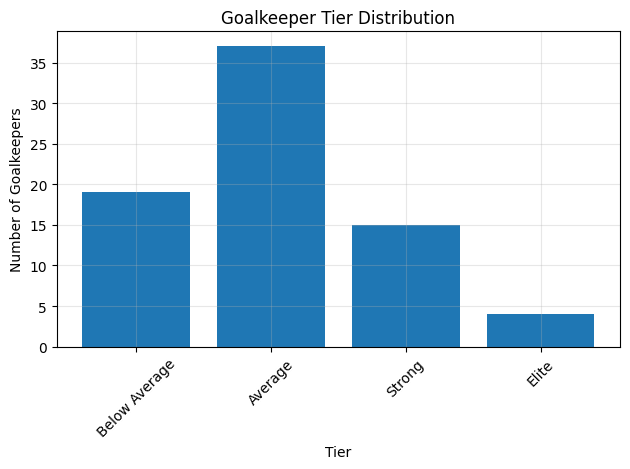

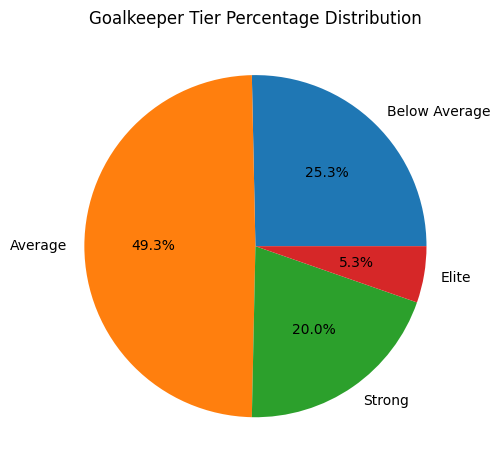

In [82]:
# Visualization Goalkeeper Tier Segmentation

tier_counts = df_gk_filtered['Tier'].value_counts().sort_index()

plt.figure()
plt.bar(tier_counts.index.astype(str), tier_counts.values)

plt.title('Goalkeeper Tier Distribution')
plt.xlabel('Tier')
plt.ylabel('Number of Goalkeepers')

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

tier_percentage = df_gk_filtered['Tier'].value_counts(normalize=True).sort_index()

plt.figure()
plt.pie(
    tier_percentage.values,
    labels=tier_percentage.index.astype(str),
    autopct='%1.1f%%'
)

plt.title('Goalkeeper Tier Percentage Distribution')
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Tier Validation'}>

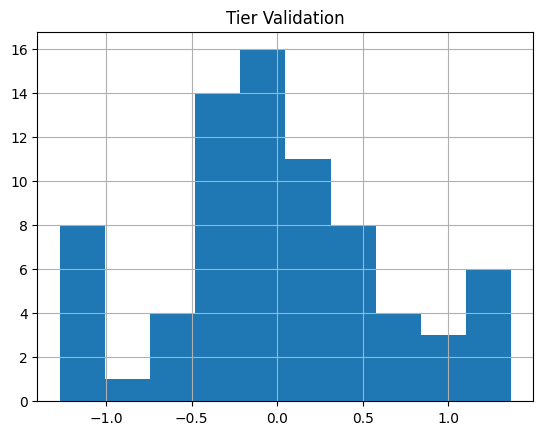

In [83]:
# Tier Validation


plt.title('Tier Validation')
df_gk_filtered['GK_Index_adj'].hist()

In [84]:
# Tier Summary

tier_summary = df_gk_filtered.groupby('Tier')[[
    'GA_per90',
    'Saves_per90',
    'CS_per90',
    'Save%',
    'PKsv_per90',
    'PrgP_per90',
    'Cmp%'
]].mean().round(3)

tier_summary

/tmp/ipykernel_427/3215320045.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_summary = df_gk_filtered.groupby('Tier')[[


,GA_per90,Saves_per90,CS_per90,Save%,PKsv_per90,PrgP_per90,Cmp%
Tier,,,,,,,
Below Average,1.634,2.622,0.185,64.542,0.019,0.057,65.958
Average,1.329,2.791,0.294,70.800,0.035,0.033,72.841
Strong,0.980,2.992,0.349,78.093,0.041,0.059,74.293
Elite,1.102,4.081,0.357,80.875,0.060,0.012,70.900


In [89]:
# Elite Goalkeeper Index Decomposition

elite_gk = df_gk_filtered[df_gk_filtered['Tier'] == 'Elite'].copy()

elite_gk = elite_gk.sort_values('GK_Index_adj', ascending=False).reset_index(drop=True)

elite_gk.head(10)




,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,GA_per90_z,Saves_per90_z,CS_per90_z,Save%_z,PKsv_per90_z,PrgP_per90_z,Cmp%_z,GK_Index,GK_Index_adj,Tier
0,1839,Ivan Provedel,it ITA,GK,Lazio,it Serie A,31.0,1994.0,20,20,...,1.388183,0.863571,1.755979,1.895058,-0.759183,0.095752,0.623060,1.327447,1.365099,Elite
1,142,Emil Audero,id IDN,GK,Cremonese,it Serie A,28.0,1997.0,15,15,...,0.682250,2.030299,0.420862,1.895058,-0.759183,-0.615310,-0.863586,0.684091,1.324863,Elite
2,1175,Hervé Koffi,bf BFA,GK,Angers,fr Ligue 1,29.0,1996.0,15,15,...,0.682250,1.818166,0.420862,1.668820,2.279050,-0.615310,-0.009319,0.777548,1.317154,Elite
3,702,Aarón Escandell,es ESP,GK,Oviedo,es La Liga,30.0,1995.0,19,19,...,-0.395228,3.074213,-0.141293,1.268554,1.639422,-0.615310,0.079436,0.424787,1.291470,Elite


In [88]:
for tier in df_gk_filtered['Tier'].unique():
    print(f"\n===== {tier} =====")
    display(
        df_gk_filtered[df_gk_filtered['Tier'] == tier][
            ['Player', 'Comp', 'GK_Index_adj']
        ].sort_values(by='GK_Index_adj', ascending=False).reset_index(drop=True)
    )


===== Below Average =====


,Player,Comp,GK_Index_adj
0,Martin Dúbravka,eng Premier League,-0.357025
1,Matz Sels,eng Premier League,-0.375236
2,Frederik Rønnow,de Bundesliga,-0.392451
3,Nicola Leali,it Serie A,-0.403639
4,Julen Agirrezabala,es La Liga,-0.444912
5,Alisson,eng Premier League,-0.470969
6,Unai Simón,es La Liga,-0.554214
7,Antonio Sivera,es La Liga,-0.569623
8,Bernd Leno,eng Premier League,-0.592161
9,Guillaume Restes,fr Ligue 1,-0.634860



===== Average =====


,Player,Comp,GK_Index_adj
0,Nick Pope,eng Premier League,0.358968
1,Elia Caprile,it Serie A,0.317846
2,Yehvann Diouf,fr Ligue 1,0.247425
3,Alexander Nübel,de Bundesliga,0.247053
4,Mark Flekken,de Bundesliga,0.233888
5,Augusto Batalla,es La Liga,0.188390
6,Mathew Ryan,es La Liga,0.167174
7,Dean Henderson,eng Premier League,0.139843
8,Mike Penders,fr Ligue 1,0.128148
9,Paulo Gazzaniga,es La Liga,0.086085



===== Elite =====


,Player,Comp,GK_Index_adj
0,Ivan Provedel,it Serie A,1.365099
1,Emil Audero,it Serie A,1.324863
2,Hervé Koffi,fr Ligue 1,1.317154
3,Aarón Escandell,es La Liga,1.291470



===== Strong =====


,Player,Comp,GK_Index_adj
0,Mile Svilar,it Serie A,1.280580
1,Jean Butez,it Serie A,1.201573
2,Sergio Herrera,es La Liga,1.046818
3,Robin Risser,fr Ligue 1,1.031086
4,Luiz Lúcio Reis Júnior,es La Liga,0.946683
5,Arijanet Muric,it Serie A,0.834217
6,Mike Maignan,it Serie A,0.743405
7,Ionuț Radu,es La Liga,0.689138
8,Robin Roefs,eng Premier League,0.641606
9,Marko Dmitrović,es La Liga,0.500338


In [95]:
# Goalkeeper Data After EDA

Full_Goalkeeper_List = (
    df_gk_filtered
    .sort_values('GK_Index_adj', ascending=False)
    .reset_index(drop=True)
)

Full_Goalkeeper_List.head(75)

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,GA_per90_z,Saves_per90_z,CS_per90_z,Save%_z,PKsv_per90_z,PrgP_per90_z,Cmp%_z,GK_Index,GK_Index_adj,Tier
0,1839,Ivan Provedel,it ITA,GK,Lazio,it Serie A,31.0,1994.0,20,20,...,1.388183,0.863571,1.755979,1.895058,-0.759183,0.095752,0.623060,1.327447,1.365099,Elite
1,142,Emil Audero,id IDN,GK,Cremonese,it Serie A,28.0,1997.0,15,15,...,0.682250,2.030299,0.420862,1.895058,-0.759183,-0.615310,-0.863586,0.684091,1.324863,Elite
2,1175,Hervé Koffi,bf BFA,GK,Angers,fr Ligue 1,29.0,1996.0,15,15,...,0.682250,1.818166,0.420862,1.668820,2.279050,-0.615310,-0.009319,0.777548,1.317154,Elite
3,702,Aarón Escandell,es ESP,GK,Oviedo,es La Liga,30.0,1995.0,19,19,...,-0.395228,3.074213,-0.141293,1.268554,1.639422,-0.615310,0.079436,0.424787,1.291470,Elite
4,2169,Mile Svilar,rs SRB,GK,Roma,it Serie A,26.0,1999.0,20,20,...,1.917634,0.227174,1.355444,2.103892,-0.759183,-0.615310,0.489927,1.283166,1.280580,Strong
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70,1240,Senne Lammens,be BEL,GK,Manchester Utd,eng Premier League,23.0,2002.0,15,15,...,-0.200167,-1.045619,-1.181280,-1.550713,-0.759183,1.280855,-1.507060,-0.918686,-1.164036,Below Average
71,1884,Álex Remiro,es ESP,GK,Real Sociedad,es La Liga,30.0,1995.0,19,19,...,-0.255899,-1.447554,-1.827758,-1.620324,-0.759183,0.881663,0.456644,-0.882043,-1.220692,Below Average
72,140,Noah Atubolu,de GER,GK,Freiburg,de Bundesliga,23.0,2002.0,16,16,...,-0.961252,-0.866633,-0.246697,-2.212022,0.664989,2.051173,-0.175735,-0.737157,-1.227321,Below Average
73,1795,Lucas Perri,br BRA,GK,Leeds United,eng Premier League,28.0,1997.0,16,16,...,-1.292158,-0.866633,-0.747367,-1.585518,-0.759183,-0.615310,-1.640192,-1.178151,-1.253771,Below Average


In [96]:
# Data Conversion & Download

from google.colab import auth
auth.authenticate_user()

import gspread
from gspread_dataframe import set_with_dataframe
from google.auth import default

creds, _ = default()
gc = gspread.authorize(creds)

# Buat spreadsheet baru
sh = gc.create("Goalkeeper Final Ranking")

# Pilih sheet pertama
worksheet = sh.get_worksheet(0)

# Kirim dataframe
set_with_dataframe(worksheet, Full_Goalkeeper_List)

print("Google Sheet URL:", sh.url)

Google Sheet URL: https://docs.google.com/spreadsheets/d/1RAZ3x7cPQP2J-eDTW1Uecu__kK2V-WkEY7csGSCGNDQ
